### EDA

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import (StandardScaler, LabelEncoder, OneHotEncoder)
from sklearn.impute import SimpleImputer 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('loan_approved_cleaned.csv')
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.5,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.3,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.2,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.3,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.3,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


Loan_Approved
0    702
1    298
Name: count, dtype: int64
Overall approval rate: 29.80%


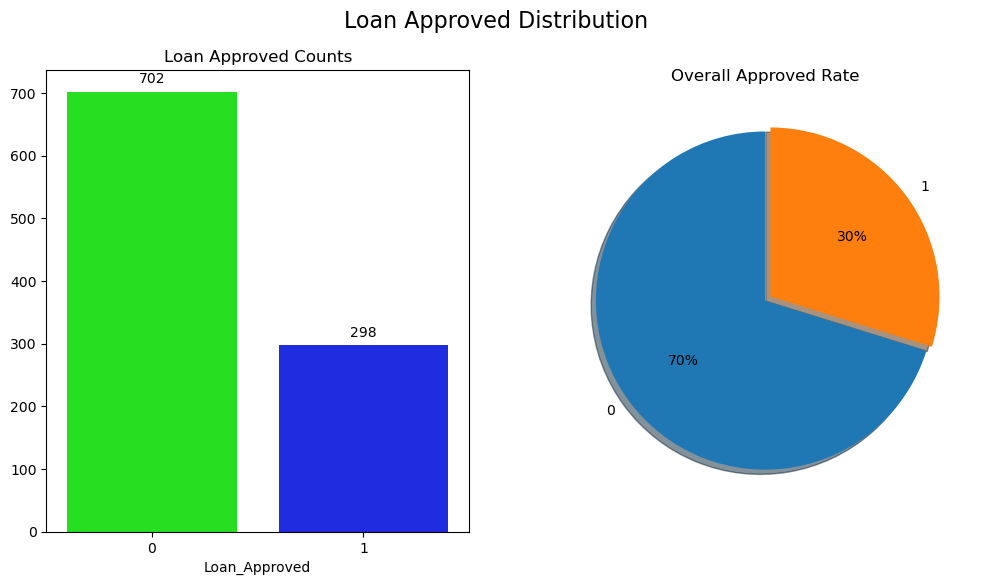

In [3]:
# Loan approved Distribution 

approve_cnt = df['Loan_Approved'].value_counts()
print(approve_cnt)

approved_pct = (approve_cnt.iloc[1] / sum(approve_cnt)) * 100
print(f"Overall approval rate: {approved_pct:.2f}%")

fig, axes = plt.subplots(1,2, figsize=(12,6))

ax = sns.barplot(x=approve_cnt.index, y=approve_cnt.values, palette='hsv', ax=axes[0])
for container in ax.containers: 
    ax.bar_label(container, fmt='%d', padding=4)
axes[0].set_title("Loan Approved Counts")
    


axes[1].pie(approve_cnt.values, labels=approve_cnt.index, autopct='%1.f%%', explode=[0,0.04], shadow=True, startangle=90)
axes[1].set_title("Overall Approved Rate")

plt.suptitle("Loan Approved Distribution", fontsize=16)
plt.show()



In [4]:
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Loan_Approved', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'],
      dtype='object')

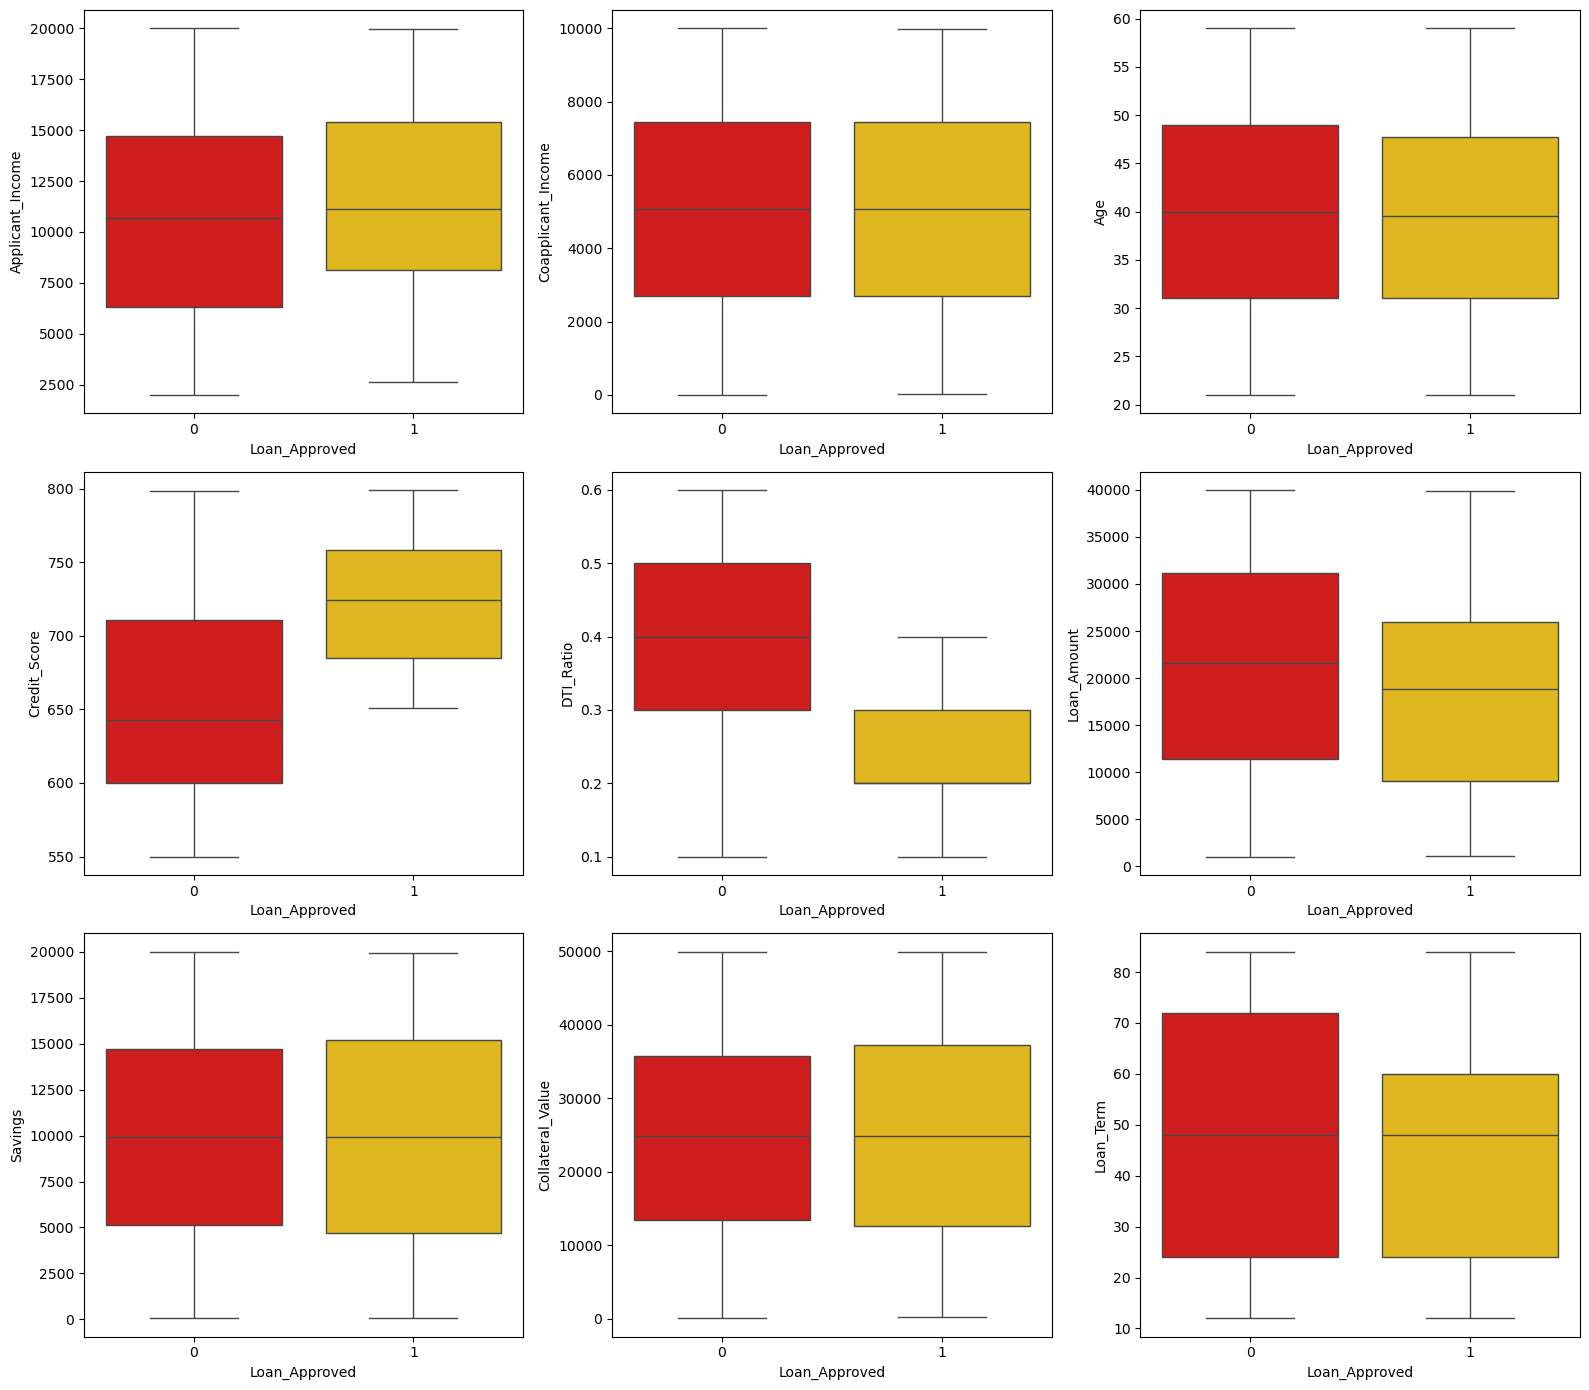

In [5]:
# Detecting Outliers  
fig,axes = plt.subplots(3,3, figsize=(16,14))
axes = axes.flatten()

cols = ['Applicant_Income', 'Coapplicant_Income', 'Age', 'Credit_Score', 'DTI_Ratio', 'Loan_Amount', 'Savings', 'Collateral_Value', 'Loan_Term']

for i, col in enumerate(cols): 
    sns.boxplot(
        data=df, 
        x='Loan_Approved', 
        y=col, 
        palette='hot', 
        ax=axes[i]
    )

plt.tight_layout()
plt.show()

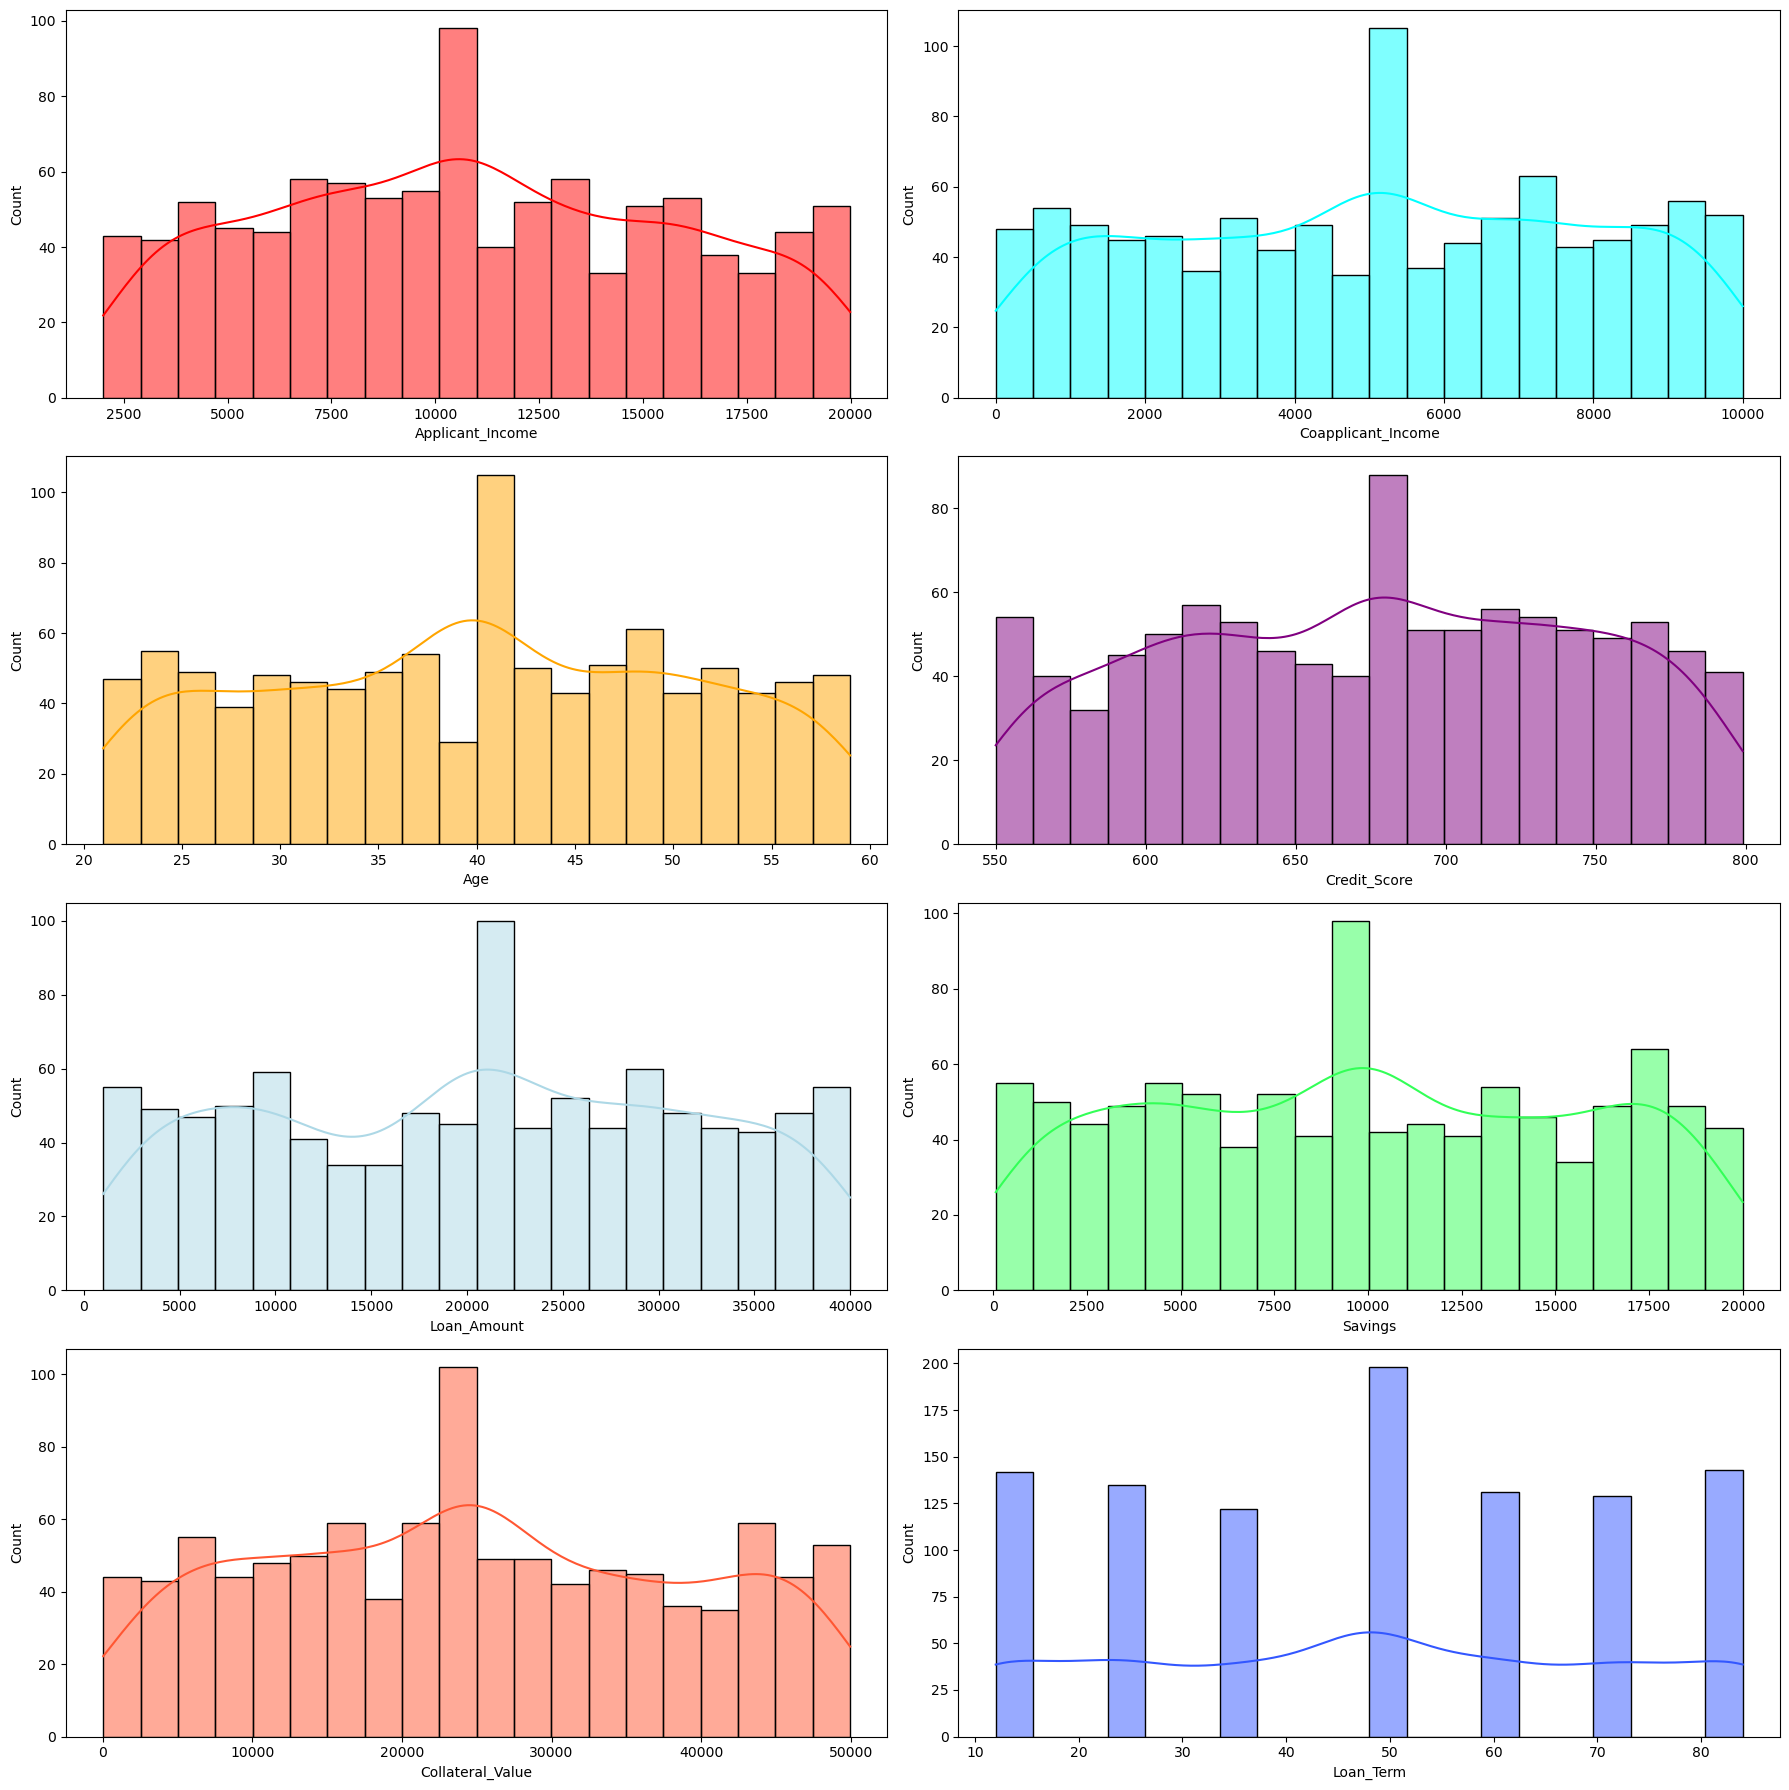

In [6]:
# Histogram 
# Detecting Outliers  
fig,axes = plt.subplots(4,2, figsize=(18,18))
axes = axes.flatten()

cols = ['Applicant_Income', 'Coapplicant_Income', 'Age', 'Credit_Score', 'Loan_Amount', 'Savings', 'Collateral_Value', 'Loan_Term']
colors = ['red', 'cyan', 'orange', 'purple', 'lightblue', '#33FF57', '#FF5733', '#3357FF']

for c, (i, col) in zip(colors, enumerate(cols)): 
    sns.histplot(
        data=df,  
        x=col, 
        color=c,
        kde=True,
        bins=20,
        ax=axes[i]
    )

plt.tight_layout()
plt.show()


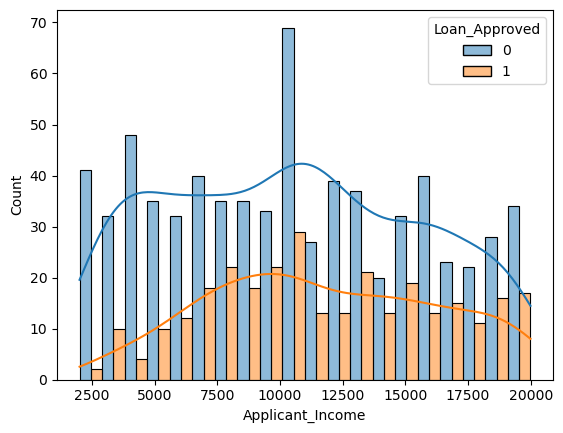

In [7]:
sns.histplot(
    data=df, 
    x='Applicant_Income', 
    hue='Loan_Approved', 
    kde=True, 
    bins=20, 
    multiple='dodge'
    
)

plt.show()

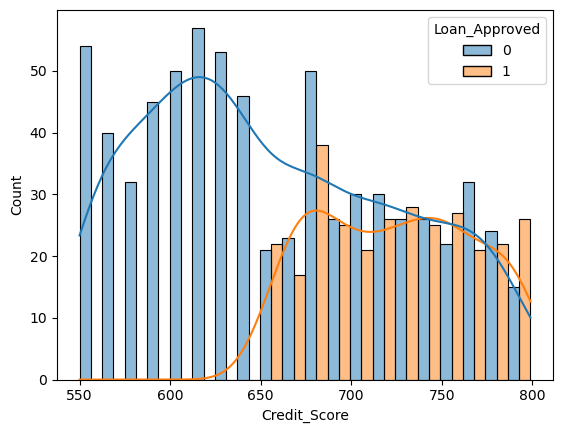

In [8]:
sns.histplot(
    data=df, 
    x='Credit_Score', 
    hue='Loan_Approved', 
    kde=True, 
    bins=20, 
    multiple='dodge'
    
)

plt.show()

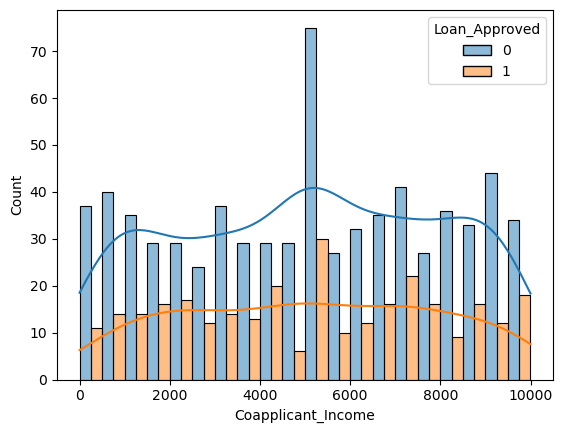

In [9]:
sns.histplot(
    data=df, 
    x='Coapplicant_Income', 
    hue='Loan_Approved', 
    kde=True, 
    bins=20, 
    multiple='dodge'
    
)

plt.show()

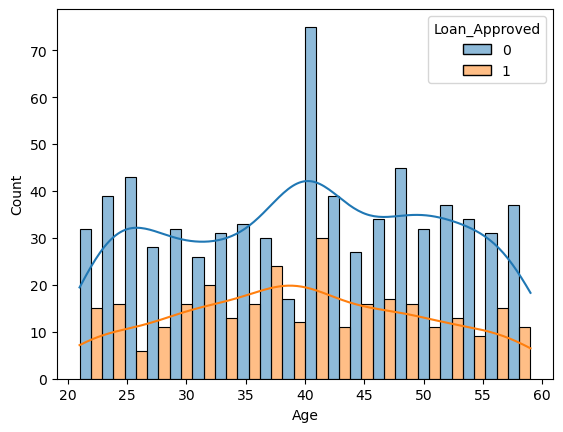

In [10]:
sns.histplot(
    data=df, 
    x='Age', 
    hue='Loan_Approved', 
    kde=True, 
    bins=20, 
    multiple='dodge'
    
)

plt.show()

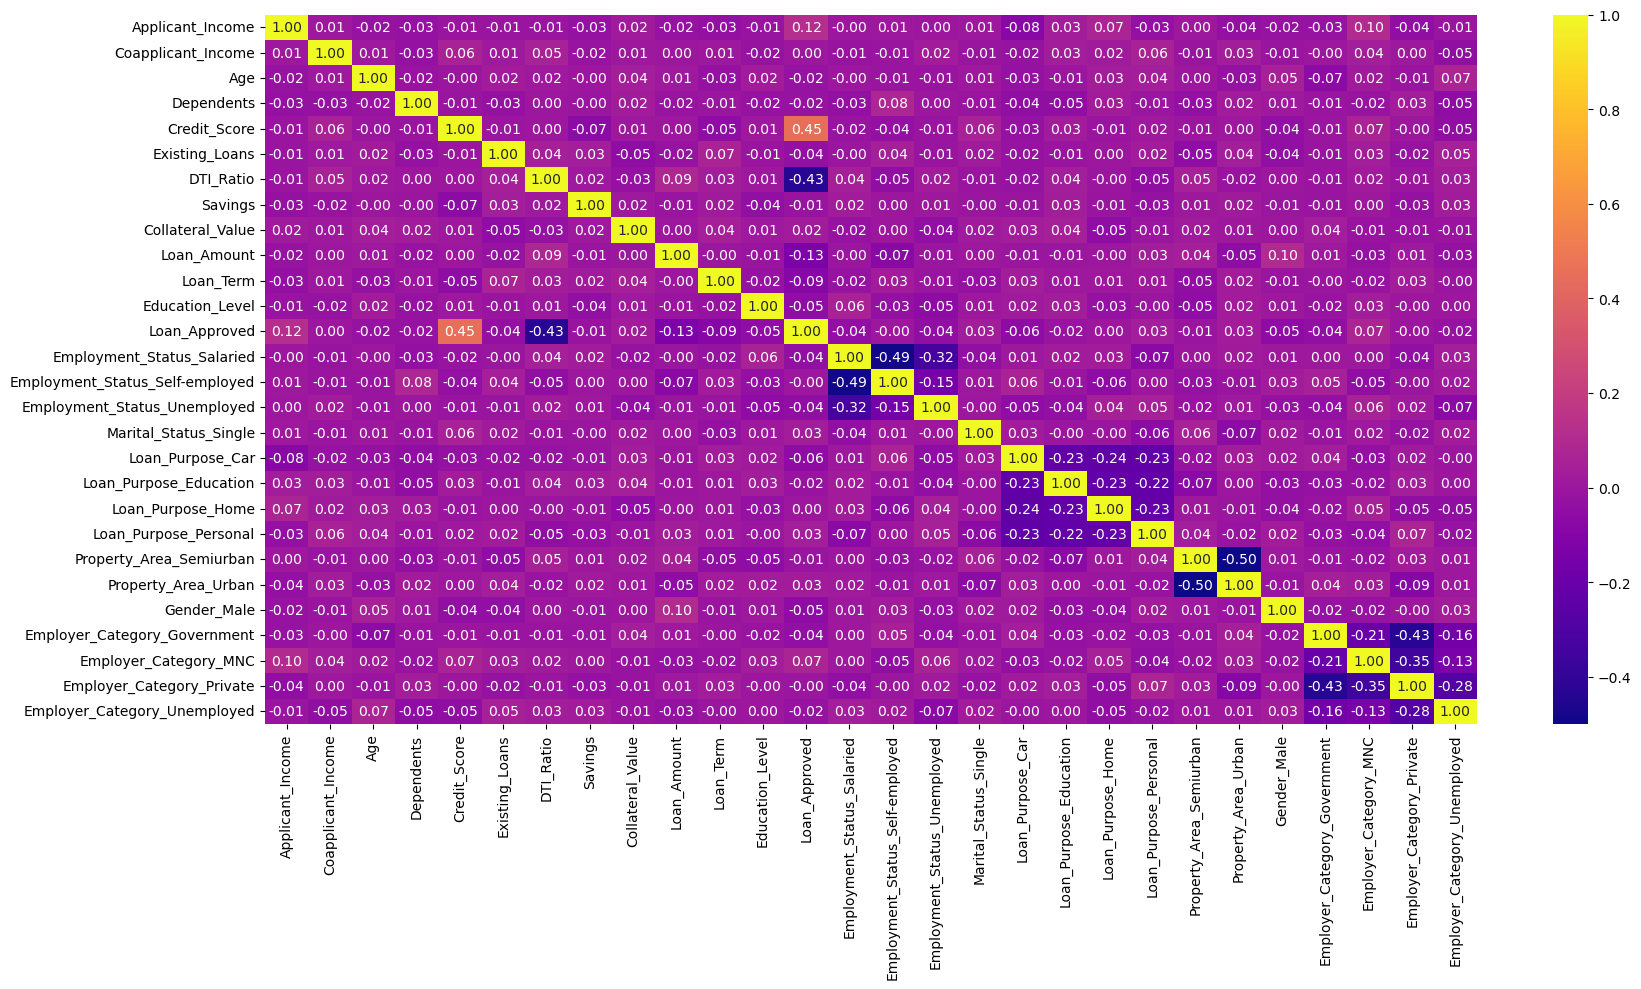

In [14]:
plt.figure(figsize=(18,10))
sns.heatmap(
    df.corr(numeric_only=True), 
    annot=True, 
    cmap='plasma', 
    fmt='.2f'
)
plt.tight_layout()
plt.show()

In [15]:
df.corr(numeric_only=True)['Loan_Approved'].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451174
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022354
Dependents                        -0.024063
Existing_Loans                    -0.035101
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

In [17]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.5,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.3,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.2,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.3,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.3,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
